In [ ]:
print("Setup and computation")

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import gaussian_kde
from pathlib import Path
import mavenn

import sys
sys.path.insert(0, str(Path('../../src').resolve()))
sys.path.insert(0, str(Path('..').resolve()))
from landscape import Landscape
from cgf import psi_1, psi_2
import style_config as sc

OUT_DIR = Path(".")
FIG2_DIR = Path("../fig2")


def estimate_p_gap_0(theta_lc):
    L = theta_lc.shape[0]
    gaps = np.array([np.sort(theta_lc[l])[-1] - np.sort(theta_lc[l])[-2]
                     for l in range(L)])
    reflected = np.concatenate([gaps, -gaps])
    kde = gaussian_kde(reflected)
    return 2.0 * kde(0.0)[0]


def gen_model(eps, Q, a, alpha):
    return Q + a * eps**alpha


def analyze(theta, label):
    L, C = theta.shape
    land = Landscape(theta)
    f_max = land.F_max
    mu = psi_1(theta, 0.0)
    sigma = np.sqrt(psi_2(theta, 0.0))
    p_gap_0 = estimate_p_gap_0(theta)

    F_fine = np.linspace(mu, f_max - 1e-3, 500)
    eps_vals = (f_max - F_fine) / L

    rho_sp = land.density(F_fine, method="saddlepoint")
    log_rho_sp = np.full_like(F_fine, np.nan)
    ok = rho_sp > 0
    log_rho_sp[ok] = np.log(rho_sp[ok])

    log_rho_bulk = (L * np.log(C)
                    - 0.5 * np.log(2 * np.pi * sigma**2)
                    - (F_fine - mu)**2 / (2 * sigma**2))

    R_theory = np.pi**2 / 3 * p_gap_0
    log_rho_peak_theory = np.sqrt(R_theory * L * (f_max - F_fine))

    eps_max = (f_max - mu) / L
    mask_fit = ok & (eps_vals < 0.2 * eps_max) & (eps_vals > 1e-6)
    Q_offset = np.nanmean(log_rho_sp[mask_fit] - log_rho_peak_theory[mask_fit])
    log_rho_peak = Q_offset + log_rho_peak_theory

    a_theory = np.sqrt(R_theory * L)
    popt, _ = curve_fit(gen_model, eps_vals[mask_fit], log_rho_sp[mask_fit],
                        p0=[Q_offset, a_theory, 0.5], maxfev=10000)
    Q_fit, a_fit, alpha_fit = popt
    gamma_fit = (2 * alpha_fit - 1) / (1 - alpha_fit)
    log_rho_fit = gen_model(eps_vals, *popt)

    print(f"  {label}: L={L}, C={C}, p_gap(0)={p_gap_0:.4f}, "
          f"alpha={alpha_fit:.3f}, gamma={gamma_fit:+.2f}")

    return dict(
        label=label, L=L, C=C,
        F=F_fine, f_max=f_max, mu=mu,
        log_sp=log_rho_sp, log_bulk=log_rho_bulk,
        log_peak=log_rho_peak, log_fit=log_rho_fit,
        ok=ok, alpha_fit=alpha_fit, gamma_fit=gamma_fit,
    )


print("\n(a) Simulated, L=100, C=4")
theta_a = np.load(FIG2_DIR / "theta_sim_L100_C4.npy")
res_a = analyze(theta_a, "Simulated")

print("\n(b) Simulated, L=100, C=20")
theta_b = np.load(FIG2_DIR / "theta_sim_L100_C20.npy")
res_b = analyze(theta_b, "Simulated")

print("\n(c) lac promoter, L=75, C=4")
lac_model = mavenn.load_example_model('sortseq_mpa_additive')
theta_c = lac_model.get_theta(gauge='consensus')['theta_lc']
res_c = analyze(theta_c, r"$\it{lac}$ promoter")

print("\n(d) GB1 protein, L=55, C=20")
gb1_model = mavenn.load_example_model('gb1_ge_additive')
theta_d = gb1_model.get_theta(gauge='consensus')['theta_lc']
res_d = analyze(theta_d, "GB1 protein")

results = [res_a, res_b, res_c, res_d]

print("\n--- Summary table ---")
print(f"{'Landscape':<20s} {'L':>4s} {'C':>4s} {'alpha':>8s} {'gamma':>8s}")
for r in results:
    print(f"{r['label']:<20s} {r['L']:4d} {r['C']:4d} "
          f"{r['alpha_fit']:8.3f} {r['gamma_fit']:+8.2f}")

Figure 4: Near-peak scaling for general alphabets — 2x2 layout
  (a)  Simulated, $L{=}100$, $C{=}4$: F_cross=64.57, r=0.331
  (b)  Simulated, $L{=}100$, $C{=}20$: F_cross=118.40, r=0.338
  (c)  $\it{lac}$ promoter, $L{=}75$, $C{=}4$: F_cross=9.70, r=0.256
  (d)  GB1 protein, $L{=}55$, $C{=}20$: F_cross=8.99, r=0.278


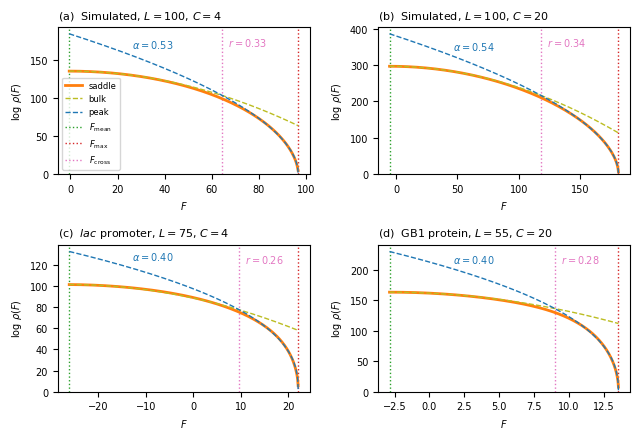

Saved fig4.pdf and fig4.png


In [2]:
print("Figure 4: Near-peak scaling for general alphabets — 2x2 layout")

subtitles = [
    "(a)  Simulated, $L{=}100$, $C{=}4$",
    "(b)  Simulated, $L{=}100$, $C{=}20$",
    r"(c)  $\it{lac}$ promoter, $L{=}75$, $C{=}4$",
    "(d)  GB1 protein, $L{=}55$, $C{=}20$",
]

fig, axes = plt.subplots(2, 2, figsize=sc.FIGSIZE_2x2)

for idx, (ax, res, sub) in enumerate(zip(axes.flat, results, subtitles)):
    F = res["F"]
    ok = res["ok"]

    ax.plot(F[ok], res["log_sp"][ok], **sc.STYLES["saddle"])
    ax.plot(F, res["log_bulk"], **sc.STYLES["bulk"])
    ax.plot(F, res["log_fit"], **sc.STYLES["peak"])

    # Alpha label at ~25% along F axis, with horizontal padding
    F_lo, F_hi = F[ok].min(), F[ok].max()
    F_label = F_lo + 0.25 * (F_hi - F_lo)
    idx_label = np.argmin(np.abs(F - F_label))
    y_label = res["log_fit"][idx_label] + 4
    alpha_str = f"{res['alpha_fit']:.2f}"
    ax.text(F_label, y_label, r"  $\alpha=" + alpha_str + r"$",
            fontsize=sc.ANNOTATION_FONTSIZE, color=sc.STYLES["peak"]["color"],
            va="bottom", ha="left")

    # Crossover: where |log_sp - log_fit| = |log_sp - log_bulk|
    err_fit = np.abs(res["log_sp"] - res["log_fit"])
    err_bulk = np.abs(res["log_sp"] - res["log_bulk"])
    diff = err_fit - err_bulk
    valid = ok & np.isfinite(diff)
    F_cross = None
    for i in range(len(F) - 1):
        if valid[i] and valid[i+1] and diff[i] > 0 and diff[i+1] <= 0:
            w = diff[i] / (diff[i] - diff[i+1])
            F_cross = F[i] + w * (F[i+1] - F[i])
            break

    ax.axvline(res["mu"], **sc.STYLES["F_mean"])
    ax.axvline(res["f_max"], **sc.STYLES["F_max"])

    if F_cross is not None:
        r_val = (res["f_max"] - F_cross) / (res["f_max"] - res["mu"])
        ax.axvline(F_cross, **sc.STYLES["F_cross"])
        ylim_tmp = ax.get_ylim()

    ax.set_ylim(bottom=0)
    ax.set_xlabel(r"$F$")
    ax.set_ylabel(r"$\log\,\rho(F)$")
    ax.set_title(sub, fontsize=sc.PANEL_TITLE_SIZE, loc="left")

    if idx == 0:
        ax.legend(**sc.LEGEND_KW, loc="lower left")

    if F_cross is not None:
        ylim = ax.get_ylim()
        y_pos = ylim[0] + 0.90 * (ylim[1] - ylim[0])
        ax.text(F_cross, y_pos, f"  $r={r_val:.2f}$",
                fontsize=sc.ANNOTATION_FONTSIZE, color=sc.STYLES["F_cross"]["color"],
                va="center", ha="left")
        print(f"  {sub}: F_cross={F_cross:.2f}, r={r_val:.3f}")

fig.tight_layout()
fig.savefig(OUT_DIR / "fig4.pdf", bbox_inches="tight")
fig.savefig(OUT_DIR / "fig4.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved fig4.pdf and fig4.png")